# Mobile Price Analysis

In [66]:
# importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import seaborn as sns
from scipy import stats
from scipy.stats import (
    skew,
    kurtosis,
    mode,
    pearsonr,
    spearmanr,
    f_oneway,
    kruskal,
    chi2_contingency,
    levene,
    shapiro
)

### Chargement des données

In [67]:
df = pd.read_csv("/content/train.csv")
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Les colonnes de l'ensemble de données sont les suivantes :

    id - Identifiant
    battery_power - Énergie totale qu'une batterie peut stocker en une seule charge, mesurée en mAh
    blue - Dispose-t-il du Bluetooth ou non ?
    clock_speed - Vitesse à laquelle le microprocesseur exécute les instructions
    dual_sim - Prend-il en charge la double carte SIM ou non ?
    fc - Nombre de mégapixels de la caméra avant
    four_g - Prise en charge de la 4G ou non
    int_memory - Mémoire interne en gigaoctets
    m_dep - Épaisseur du téléphone en cm
    mobile_wt - Poids du téléphone
    n_cores - Nombre de cœurs du processeur
    pc - Nombre de mégapixels de l'appareil photo principal
    px_height - Hauteur de la résolution en pixels
    px_width - Largeur de la résolution en pixels
    ram - Mémoire vive en mégaoctets
    sc_h - Hauteur de l'écran du téléphone en cm
    sc_w - Largeur de l'écran du téléphone en cm
    talk_time - Durée maximale d'autonomie d'une seule charge de batterie en communication
    three_g - Prise en charge de la 3G ou non
    touch_screen - Écran tactile ou non
    wifi - Prise en charge du Wi-Fi ou non
    price_range - Il s'agit de la variable cible dont la valeur peut être :
        0 (bas de gamme)
        1 (milieu de gamme)
        2 (haut de gamme)
        3 (très haut de gamme)

In [68]:
print(f"Nombre de lignes : {df.shape}") # dimension du dataset

Nombre de lignes : (2000, 21)


In [69]:
df.dtypes

,0
battery_power,int64
blue,int64
clock_speed,float64
dual_sim,int64
fc,int64
four_g,int64
int_memory,int64
m_dep,float64
mobile_wt,int64
n_cores,int64


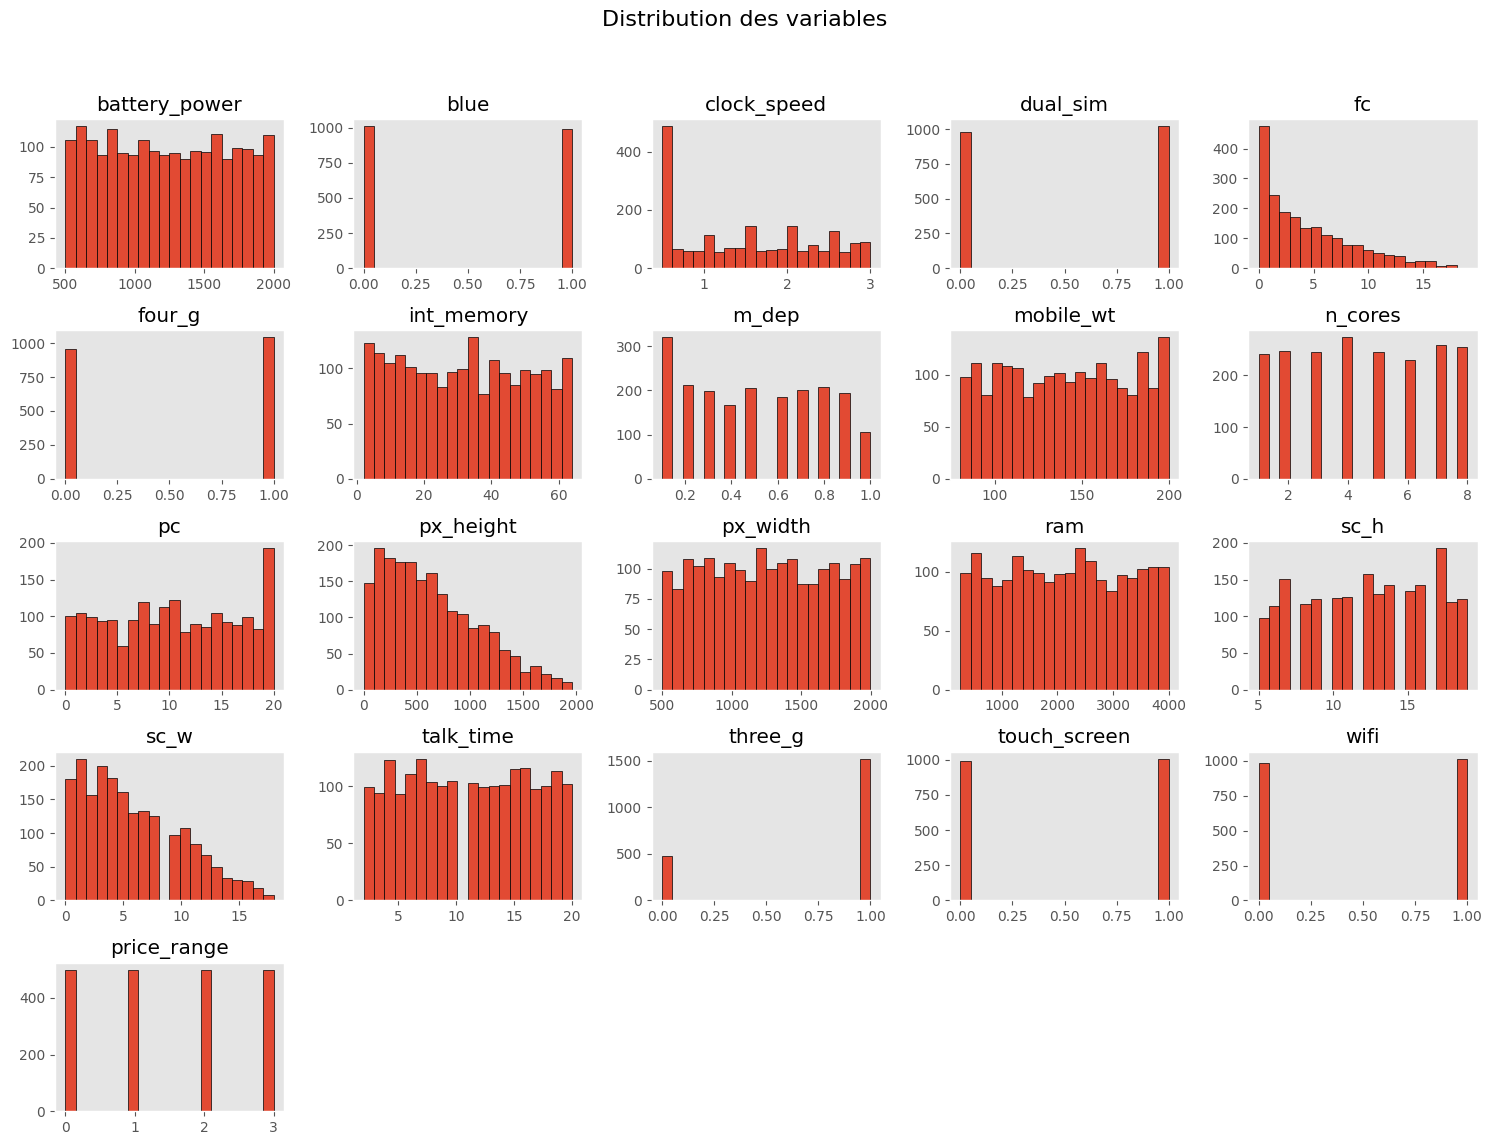

In [71]:
# Représentation des distributions des variables quantitatives
df[df.columns.tolist()].hist(figsize=(15, 12), bins=20, grid=False, edgecolor='black')
plt.suptitle('Distribution des variables', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Les variables binaires (blue, dual_sim, four_g, three_g, touch_screen, wifi) ne peuvent pas suivre une distribution normale.

Les variables discrètes (clock_speed, n_cores, pc) présentent des distributions en paliers, incompatibles avec une loi normale.

Les variables asymétriques (fc, px_height, sc_w) montrent un déséquilibre marqué vers les faibles valeurs.

les variables quasi uniformes (battery_power, ram, int_memory) ne présentent pas la forme en cloche caractéristique d'une distribution normale.

commentaires : Le jeu de données est bien équilibré, notamment pour la variable cible price_range, ce qui est favorable à la construction d'un modèle de classification performant.
La majorité des variables ne suivent pas une distribution normale. Les histogrammes mettent en évidence des distributions uniformes, asymétriques, discrètes ou binaires.
Les variables fc, px_height et sc_w présentent une forte asymétrie positive, indiquant que les faibles valeurs sont les plus fréquentes.
Les variables binaires (blue, dual_sim, four_g, three_g, touch_screen et wifi) sont relativement équilibrées, mais leur nature dichotomique explique leur non-normalité.
Les variables battery_power, ram, int_memory, mobile_wt et px_width couvrent une large plage de valeurs avec une répartition relativement homogène, ce qui suggère une bonne diversité des caractéristiques des smartphones.

In [72]:
# Calculer le nombre de lignes en doublons
num_duplicates = df.duplicated().sum()
print(f"Nombre de lignes en doublons : {num_duplicates}")

Nombre de lignes en doublons : 0


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

Nous ne disposons pas de valeur manquantes dans le jeu données

### Analyse Statistique

In [74]:
# Séparer les variables numériques
target = "price_range"
features = [col for col in df.columns if col != target]

In [75]:
summary = []

for col in features:

    mean = np.mean(df[col])
    median = np.median(df[col])
    mode_value = stats.mode(df[col], keepdims=True).mode[0]

    minimum = np.min(df[col])
    maximum = np.max(df[col])
    data_range = maximum - minimum

    variance = np.var(df[col], ddof=1)
    std = np.std(df[col], ddof=1)

    skewness = skew(df[col])
    kurt = kurtosis(df[col])

    summary.append([
        col,
        mean,
        median,
        mode_value,
        minimum,
        maximum,
        data_range,
        variance,
        std,
        skewness,
        kurt
    ])

summary_df = pd.DataFrame(summary,
columns=[
    "Feature",
    "Mean",
    "Median",
    "Mode",
    "Min",
    "Max",
    "Range",
    "Variance",
    "Std",
    "Skewness",
    "Kurtosis"
])

summary_df

,Feature,Mean,Median,Mode,Min,Max,Range,Variance,Std,Skewness,Kurtosis
0,battery_power,1238.51850,1226.0,618.0,501.0,1998.0,1497.0,1.930884e+05,439.418206,0.031875,-1.224084
1,blue,0.49500,0.0,0.0,0.0,1.0,1.0,2.501001e-01,0.500100,0.020001,-1.999600
2,clock_speed,1.52225,1.5,0.5,0.5,3.0,2.5,6.658629e-01,0.816004,0.177951,-1.323109
3,dual_sim,0.50950,1.0,1.0,0.0,1.0,1.0,2.500348e-01,0.500035,-0.038007,-1.998555
4,fc,4.30950,3.0,0.0,0.0,19.0,19.0,1.884813e+01,4.341444,1.019046,0.273386
5,four_g,0.52150,1.0,1.0,0.0,1.0,1.0,2.496626e-01,0.499662,-0.086080,-1.992590
6,int_memory,32.04650,32.0,27.0,2.0,64.0,62.0,3.292670e+02,18.145715,0.057846,-1.216034
7,m_dep,0.50175,0.5,0.1,0.1,1.0,0.9,8.318353e-02,0.288416,0.089015,-1.274164
8,mobile_wt,140.24900,141.0,182.0,80.0,200.0,120.0,1.253136e+03,35.399655,0.006553,-1.210351
9,n_cores,4.52050,4.0,4.0,1.0,8.0,7.0,5.234197e+00,2.287837,0.003625,-1.229676


Mesures de tendance centrale

Battery Power
Moyenne : 1238.52 mAh
Médiane : 1226 mAh

La moyenne et la médiane sont très proches, indiquant une distribution presque symétrique. La capacité des batteries est relativement bien répartie entre 501 et 1998 mAh.

RAM
Moyenne : 2124 Mo
Médiane : 2146.5 Mo

Les deux valeurs sont également très proches, ce qui montre que les téléphones possèdent une répartition équilibrée de la mémoire RAM.

Cette variable présente toutefois une très grande plage :

Minimum : 256 Mo
Maximum : 3998 Mo

Cela traduit une forte diversité des performances des téléphones.

Mémoire interne (int_memory)
Moyenne : 32 Go
Médiane : 32 Go

La mémoire interne est parfaitement centrée autour de 32 Go.

Les capacités disponibles couvrent pratiquement toutes les tailles classiques (2 à 64 Go).

Variables binaires

Les variables :

Bluetooth
Dual SIM
4G
Écran tactile
WiFi

ont des moyennes proches de 0.5.

Cela signifie que le jeu de données contient presque autant de téléphones possédant ces fonctionnalités que de téléphones ne les possédant pas.

Cette bonne répartition évite un déséquilibre de classes.

Caméras

Caméra avant (fc)

moyenne = 4.31 MP
médiane = 3 MP
mode = 0 MP

La majorité des téléphones possèdent une caméra frontale de faible résolution, voire aucune.

Caméra principale (pc)

moyenne = 9.92 MP
médiane = 10 MP

La caméra arrière est beaucoup plus performante et mieux répartie.

Analyse de la dispersion

Variables les plus dispersées

La variance et l'écart-type montrent que les variables suivantes présentent la plus forte variabilité :

Variable	Écart-type
RAM	1084.73
px_height	443.78
battery_power	439.42
px_width	432.20

Cela signifie que ces caractéristiques varient fortement d'un téléphone à un autre.

Cette diversité est favorable aux algorithmes de classification puisqu'elle apporte davantage d'information.

Variables peu dispersées

Les variables binaires présentent naturellement un faible écart-type :

Bluetooth
WiFi
Dual SIM
4G
Touch Screen

avec un écart-type proche de 0.5.

3. Analyse de l'asymétrie (Skewness)

La skewness indique si la distribution est symétrique.

Variables presque symétriques

Les variables suivantes ont une asymétrie proche de zéro :

battery_power (0.03)
ram (0.006)
mobile_wt (0.007)
n_cores (0.004)
talk_time (0.01)
px_width (0.015)

Ces distributions sont quasiment normales.

Asymétrie positive

Certaines variables présentent une asymétrie vers la droite :

fc

Skewness = 1.02

Cela signifie que :

beaucoup de téléphones possèdent une faible caméra frontale ;
quelques modèles disposent de caméras frontales très performantes.

La distribution est fortement concentrée sur les petites valeurs.

px_height

Skewness = 0.67

La résolution verticale est légèrement asymétrique.

La majorité des téléphones possèdent une résolution moyenne tandis que quelques modèles disposent d'une très haute résolution.

sc_w

Skewness = 0.63

Les largeurs d'écran sont également légèrement concentrées sur les petites valeurs.

Asymétrie négative

La variable :

three_g (-1.23)

présente une asymétrie négative.

Cela signifie que la majorité des téléphones supportent la 3G.

4. Analyse de la kurtosis

Toutes les variables possèdent une kurtosis négative.

Exemples :

RAM : -1.19
Battery : -1.22
Memory : -1.21
Bluetooth : -2

Une kurtosis négative indique une distribution platykurtique :

moins de valeurs extrêmes ;
distributions plus plates qu'une loi normale.

Le jeu de données contient donc relativement peu d'outliers.

C'est un bon indicateur de qualité des données.

In [77]:
normality = []

for col in features:

    stat, p = shapiro(df[col])

    normality.append([
        col,
        stat,
        p
    ])

normality_df = pd.DataFrame(
    normality,
    columns=["Feature","Statistic","P-value"]
)

normality_df

,Feature,Statistic,P-value
0,battery_power,0.951884,4.012365e-25
1,blue,0.636578,5.074999e-54
2,clock_speed,0.911232,1.137524e-32
3,dual_sim,0.636483,5.023046e-54
4,fc,0.873743,1.738698e-37
5,four_g,0.635942,4.736917e-54
6,int_memory,0.952742,6.445697e-25
7,m_dep,0.925406,2.024814e-30
8,mobile_wt,0.952758,6.505446e-25
9,n_cores,0.926188,2.753812e-30


Le test de normalité de Shapiro-Wilk a été appliqué à l'ensemble des variables du jeu de données afin d'évaluer leur conformité à une distribution normale. Pour toutes les variables, les p-values obtenues sont largement inférieures au seuil de significativité de 0,05, conduisant au rejet de l'hypothèse nulle de normalité. Les variables binaires (blue, dual_sim, four_g, three_g, touch_screen et wifi) présentent naturellement des distributions non normales en raison de leur nature dichotomique. Les variables quantitatives montrent également des écarts significatifs à la normalité, un résultat accentué par la taille importante de l'échantillon (2 000 observations). En conséquence, les analyses statistiques privilégieront des méthodes robustes ou non paramétriques, telles que le test de Kruskal-Wallis et la corrélation de Spearman, afin de garantir des résultats fiables et adaptés aux caractéristiques des données.

#### Test non paramétrique : Kruskal-Wallis

In [78]:
kruskal_results=[]

for col in features:

    H,p = kruskal(
        df[df.price_range==0][col],
        df[df.price_range==1][col],
        df[df.price_range==2][col],
        df[df.price_range==3][col]
    )

    kruskal_results.append([
        col,
        H,
        p
    ])

kruskal_df=pd.DataFrame(
    kruskal_results,
    columns=["Feature","H","P-value"]
)

kruskal_df.sort_values("P-value")

,Feature,H,P-value
13,ram,1681.496474,0.000000e+00
0,battery_power,90.135750,2.048329e-19
12,px_width,65.230765,4.477100e-14
11,px_height,47.181408,3.180105e-10
8,mobile_wt,10.819251,1.274450e-02
6,int_memory,8.768458,3.253315e-02
9,n_cores,7.878417,4.859243e-02
14,sc_h,6.688037,8.253456e-02
16,talk_time,4.895142,1.796384e-01
7,m_dep,4.573047,2.058665e-01


Les variables les plus importantes

Les caractéristiques techniques dominantes sont :

RAM
Puissance batterie
Résolution écran (px_width, px_height)


La performance ou segmentation des classes dépend principalement de la puissance et des capacités matérielles du téléphone.

Variables secondaires
poids du téléphone (mobile_wt)
mémoire interne (int_memory)
nombre de cœurs (n_cores)

Elles influencent mais de façon plus faible :

Ce sont des facteurs secondaires de différenciation.

Variables peu utiles pour la prédiction
Bluetooth, 3G, WiFi, Dual SIM
caméra frontale/arrière (fc, pc)
écran physique (sc_h, sc_w)

Ces variables ne permettent pas de distinguer efficacement les classes dans ton dataset.

commentairre
Le dataset est fortement dominé par des variables de performance technique
4 variables expliquent l’essentiel du pouvoir discriminant :
RAM
Battery power
Résolution écran (width/height)

Les autres variables sont : soit secondaires ou soit inutiles pour la séparation des classes

#### Variables binaires : test du Chi²
Pour les variables catégorielles/binaires (blue, dual_sim, four_g, three_g, touch_screen, wifi)

In [79]:
categorical = [
    "blue",
    "dual_sim",
    "four_g",
    "three_g",
    "touch_screen",
    "wifi"
]

chi_results=[]

for col in categorical:

    table=pd.crosstab(df[col],df.price_range)

    chi2,p,dof,expected = chi2_contingency(table)

    chi_results.append([
        col,
        chi2,
        p
    ])

chi_df=pd.DataFrame(
    chi_results,
    columns=["Feature","Chi-square","P-value"]
)

chi_df

,Feature,Chi-square,P-value
0,blue,1.432143,0.698018
1,dual_sim,1.286464,0.732350
2,four_g,3.179880,0.364714
3,three_g,1.373764,0.711696
4,touch_screen,3.880140,0.274701
5,wifi,0.856168,0.835991


Toutes les p-values sont largement supérieures à 0.05
On ne rejette pas H0 pour aucune variable.
Aucune variable binaire n’expliquent pas la différence entre les classes
Les variables binaires de connectivité et fonctionnalités (Bluetooth, WiFi, 3G/4G, etc.) n’ont aucun impact statistiquement significatif sur la variable cible

#### Corrélation avec la variable cible avec Spearman

In [80]:
spearman_results=[]

for col in features:

    r,p = spearmanr(df[col],df[target])

    spearman_results.append([
        col,
        r,
        p
    ])

spearman_df=pd.DataFrame(
    spearman_results,
    columns=["Feature","Correlation","P-value"]
)

spearman_df.sort_values("Correlation",ascending=False)

,Feature,Correlation,P-value
13,ram,0.917080,0.000000e+00
0,battery_power,0.199991,1.722306e-19
12,px_width,0.165134,1.074056e-13
11,px_height,0.131884,3.215011e-09
6,int_memory,0.044278,4.771653e-02
10,pc,0.032824,1.422683e-01
15,sc_w,0.024776,2.680838e-01
4,fc,0.024167,2.800284e-01
14,sc_h,0.023727,2.888849e-01
17,three_g,0.023611,2.912366e-01


Forte dépendance entre la cible et : RAM (très forte corrélation)

Corrélations faibles mais utiles :
battery_power
px_width
px_height

Aucune structure significative pour :

variables binaires
variables techniques secondaires

#### Matrice de corrélation

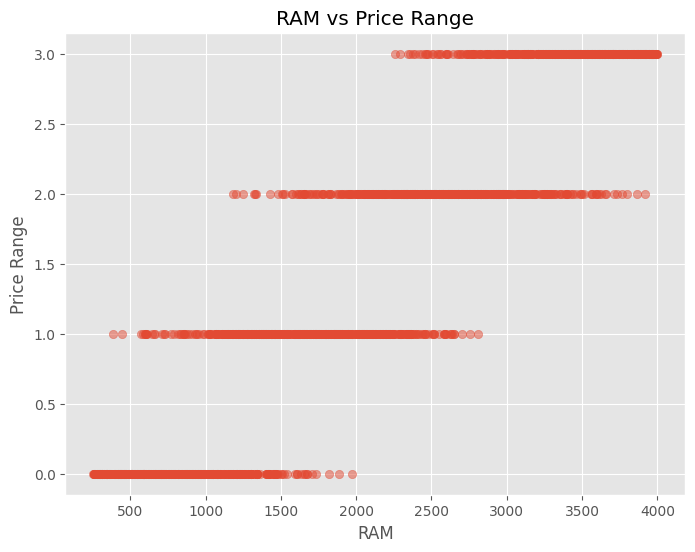

In [83]:
plt.figure(figsize=(8,6))

plt.scatter(df["ram"],
            df["price_range"],
            alpha=0.5)

plt.title("RAM vs Price Range")
plt.xlabel("RAM")
plt.ylabel("Price Range")

plt.show()

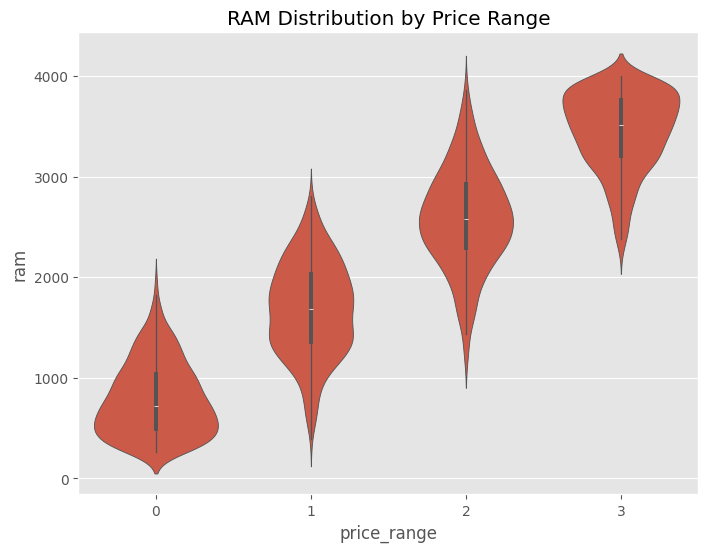

In [91]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x="price_range",
    y="ram",
    data=df
)

plt.title("RAM Distribution by Price Range")

plt.show()

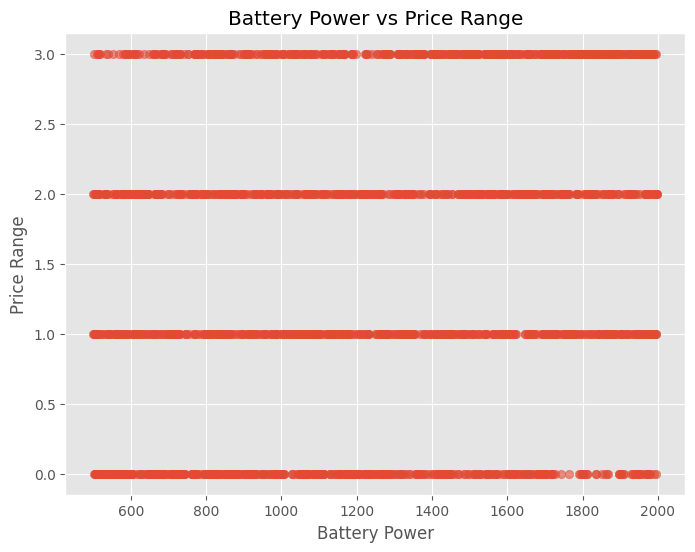

In [84]:
plt.figure(figsize=(8,6))

plt.scatter(df["battery_power"],
            df["price_range"],
            alpha=0.6)

plt.title("Battery Power vs Price Range")
plt.xlabel("Battery Power")
plt.ylabel("Price Range")

plt.show()

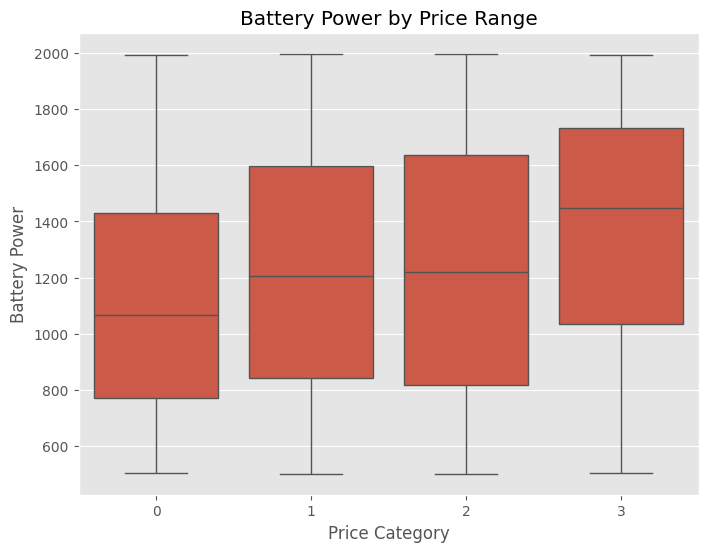

In [87]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="price_range",
    y="battery_power",
    data=df
)

plt.title("Battery Power by Price Range")
plt.xlabel("Price Category")
plt.ylabel("Battery Power")

plt.show()

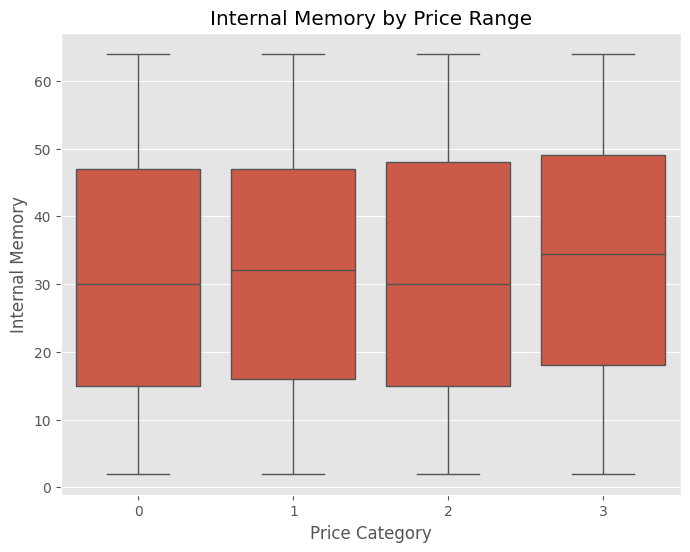

In [88]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="price_range",
    y="int_memory",
    data=df
)

plt.title("Internal Memory by Price Range")
plt.xlabel("Price Category")
plt.ylabel("Internal Memory")

plt.show()

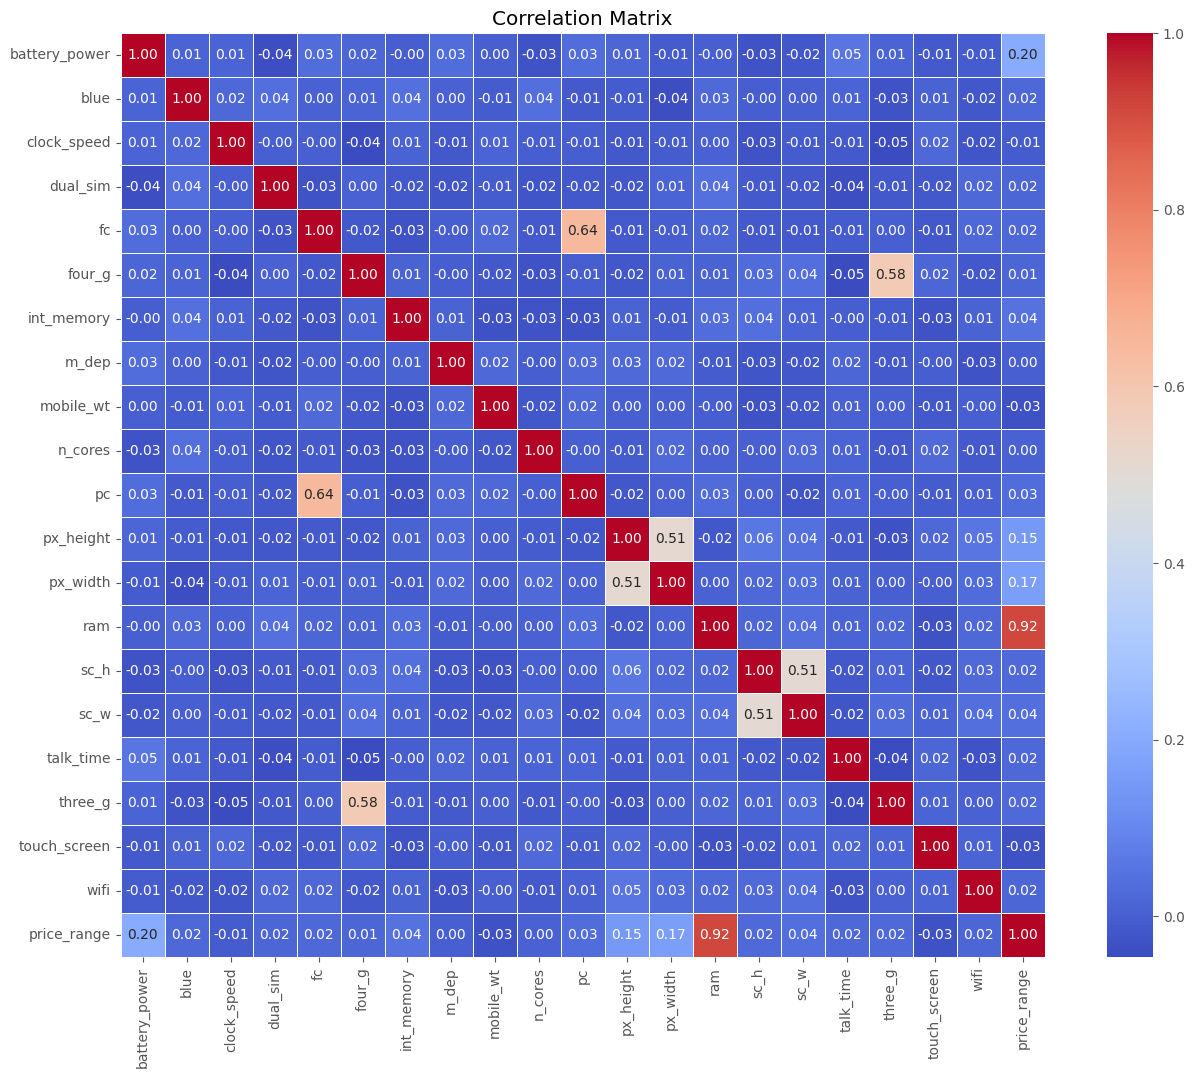

In [81]:
corr = df.corr()

plt.figure(figsize=(16,12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

la matrice de correlation confirme la Forte dépendance entre la cible et : RAM (très forte corrélation) ainsi que la
Corrélations faibles mais utiles :
battery_power
px_width
px_height